
# 01 — Centrality Bins

## Objetivo

Este notebook constrói a primeira camada de leitura do experimento: **centralidade**. Antes de olhar a forma detalhada dos espectros, primeiro entendemos como a composição total muda conforme o sistema Pb–Pb fica mais central ou mais periférico.

A centralidade é uma forma experimental de ordenar colisões Pb–Pb de acordo com o quão “frontais” elas foram.

- **0–5%**: colisões mais centrais, maior overlap entre os núcleos.
- **80–90%**: colisões mais periféricas, menor overlap.

Neste notebook vamos usar as tabelas integradas de Pb–Pb:

- `Pb-Pb/Table11.csv`: razão integrada $K/\pi$;
- `Pb-Pb/Table13.csv`: razão integrada $p/\pi$.

Essas tabelas também trazem $N_{ch}$, que usamos como proxy da multiplicidade carregada e, portanto, do tamanho efetivo do sistema produzido.



## 1. Imports e configuração

O parser abaixo é necessário porque os arquivos HEPData possuem blocos repetidos:

1. um bloco com $N_{ch}$ por centralidade;
2. outro bloco com o observável integrado por centralidade.

Em vez de usar `pd.read_csv` diretamente, vamos separar os blocos.


In [ ]:

from pathlib import Path
import csv
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.family"] = "DejaVu Sans"

DATA_DIR = Path("..")
PB_PB_DIR = DATA_DIR / "Pb-Pb"

def split_hepdata_blocks(path):
    """
    Lê um arquivo CSV estilo HEPData contendo múltiplos blocos.
    Retorna uma lista de tuplas:
        (metadata, dataframe)
    """
    path = Path(path)
    lines = path.read_text(encoding="utf-8").splitlines()

    blocks = []
    meta = {}
    header = None
    rows = []

    def flush_block():
        nonlocal header, rows
        if header is not None and rows:
            df = pd.DataFrame(rows, columns=header)

            # Converte colunas numéricas quando possível
            for col in df.columns:
                converted = pd.to_numeric(df[col], errors="coerce")
                if converted.notna().mean() > 0.5:
                    df[col] = converted

            blocks.append((meta.copy(), df))

        header = None
        rows = []

    for raw in lines:
        line = raw.strip()

        if not line:
            continue

        if line.startswith("#:"):
            content = line[2:].strip()

            # Se um novo bloco de centralidade começa depois de dados, fecha o bloco anterior
            if "CENTRALITY" in content and header is not None and rows:
                flush_block()

            if ",,," in content:
                key, value = content.split(",,,", 1)
                meta[key.strip()] = value.strip()
            elif ":" in content:
                key, value = content.split(":", 1)
                meta[key.strip()] = value.strip()
            elif "," in content:
                parts = next(csv.reader([content]))
                if parts:
                    meta[parts[0].strip()] = " | ".join(p.strip() for p in parts[1:])

            continue

        parts = [p.strip() for p in next(csv.reader([line]))]

        # Se aparece um novo cabeçalho depois de linhas de dados, fecha bloco anterior
        if header is not None and rows:
            first = parts[0]
            if any(ch.isalpha() for ch in first) or "$" in first:
                flush_block()

        if header is None:
            header = parts
        else:
            if len(parts) == len(header):
                rows.append(parts)

    flush_block()
    return blocks


def centrality_midpoint(label):
    """
    Converte uma string como '0.0-5.0' no ponto médio 2.5.
    """
    nums = re.findall(r"\d+\.?\d*", str(label))
    if len(nums) >= 2:
        return 0.5 * (float(nums[0]) + float(nums[1]))
    return np.nan



## 2. Carregando as tabelas integradas Pb–Pb

A tabela 11 contém a razão integrada:

$$
\frac{K^+ + K^-}{\pi^+ + \pi^-}
$$

A tabela 13 contém a razão integrada:

$$
\frac{p+\bar p}{\pi^+ + \pi^-}
$$

Cada uma delas vem com um bloco inicial de $N_{ch}$, que representa a multiplicidade carregada associada a cada classe de centralidade.


In [5]:

table11_path = PB_PB_DIR / "Table11.csv"
table13_path = PB_PB_DIR / "Table13.csv"

blocks11 = split_hepdata_blocks(table11_path)
blocks13 = split_hepdata_blocks(table13_path)

print(f"Table 11 possui {len(blocks11)} blocos.")
print(f"Table 13 possui {len(blocks13)} blocos.")

nch_df = blocks11[0][1].copy()
kpi_df = blocks11[1][1].copy()
esse = blocks13[0][1].copy()
ppi_df = blocks13[1][1].copy()

display(nch_df)
display(kpi_df)
display(esse)
display(ppi_df)


Table 11 possui 2 blocos.
Table 13 possui 2 blocos.


,Cent [ptc.],$N_{Ch}$,syst. +,syst. -
0,0.0-5.0,1943.00,56.00,-56.00
1,5.0-10.0,1587.00,48.00,-48.00
2,10.0-20.0,1180.00,31.00,-31.00
3,20.0-30.0,786.00,20.00,-20.00
4,30.0-40.0,512.00,15.00,-15.00
5,40.0-50.0,318.00,12.00,-12.00
6,50.0-60.0,183.00,8.00,-8.00
7,60.0-70.0,96.30,5.80,-5.80
8,70.0-80.0,44.90,3.40,-3.40
9,80.0-90.0,17.52,1.84,-1.84


,Cent [ptc.],$(K^{+}+K^{-})/(\pi^{+}+\pi^{-})$,stat. +,stat. -,syst. +,syst. -,syst. uncorr. +,syst. uncorr. -
0,0.0-5.0,0.16085,0.000220,-0.000220,0.013004,-0.013004,0.006383,-0.006383
1,5.0-10.0,0.16151,0.000401,-0.000401,0.010383,-0.010383,0.005980,-0.005980
2,10.0-20.0,0.16178,0.000241,-0.000241,0.009916,-0.009916,0.005749,-0.005749
3,20.0-30.0,0.16088,0.000221,-0.000221,0.010446,-0.010446,0.005721,-0.005721
4,30.0-40.0,0.16035,0.000214,-0.000214,0.010372,-0.010372,0.005620,-0.005620
5,40.0-50.0,0.15828,0.000242,-0.000242,0.010670,-0.010670,0.005818,-0.005818
6,50.0-60.0,0.15413,0.000318,-0.000318,0.010868,-0.010868,0.006821,-0.006821
7,60.0-70.0,0.15062,0.000379,-0.000379,0.011383,-0.011383,0.007401,-0.007401
8,70.0-80.0,0.14418,0.000531,-0.000531,0.011181,-0.011181,0.008931,-0.008931
9,80.0-90.0,0.13924,0.000786,-0.000786,0.010733,-0.010733,0.009789,-0.009789


,Cent [ptc.],$N_{Ch}$,syst. +,syst. -
0,0.0-5.0,1943.00,56.00,-56.00
1,5.0-10.0,1587.00,48.00,-48.00
2,10.0-20.0,1180.00,31.00,-31.00
3,20.0-30.0,786.00,20.00,-20.00
4,30.0-40.0,512.00,15.00,-15.00
5,40.0-50.0,318.00,12.00,-12.00
6,50.0-60.0,183.00,8.00,-8.00
7,60.0-70.0,96.30,5.80,-5.80
8,70.0-80.0,44.90,3.40,-3.40
9,80.0-90.0,17.52,1.84,-1.84


,Cent [ptc.],$(p+pbar)/(\pi^{+}+\pi^{-})$,stat. +,stat. -,syst. +,syst. -,syst. uncorr. +,syst. uncorr. -
0,0.0-5.0,0.043867,0.000044,-0.000044,0.003736,-0.003736,0.001615,-0.001615
1,5.0-10.0,0.044655,0.000056,-0.000056,0.003040,-0.003040,0.001284,-0.001284
2,10.0-20.0,0.045599,0.000047,-0.000047,0.002969,-0.002969,0.001257,-0.001257
3,20.0-30.0,0.046526,0.000058,-0.000058,0.003158,-0.003158,0.001325,-0.001325
4,30.0-40.0,0.048130,0.000070,-0.000070,0.003271,-0.003271,0.001359,-0.001359
5,40.0-50.0,0.049358,0.000090,-0.000090,0.003497,-0.003497,0.001383,-0.001383
6,50.0-60.0,0.050913,0.000124,-0.000124,0.003722,-0.003722,0.001647,-0.001647
7,60.0-70.0,0.053376,0.000180,-0.000180,0.004351,-0.004351,0.001767,-0.001767
8,70.0-80.0,0.055235,0.000287,-0.000287,0.004634,-0.004634,0.002409,-0.002409
9,80.0-90.0,0.056176,0.000496,-0.000496,0.004790,-0.004790,0.003081,-0.003081



## 3. Gráfico 1 — $N_{ch}$ vs centralidade

Este é o gráfico mais importante para visualizar a **o tamanho da colisão**.

A centralidade não mede diretamente o parâmetro de impacto, mas está fortemente relacionada com ele.

- Baixo percentil de centralidade $0\text{–}5\%$: colisões mais frontais.
- Alto percentil de centralidade $80\text{–}90\%$: colisões periféricas.

Quando a colisão é mais central, o overlap entre os núcleos é maior, mais matéria é produzida e a multiplicidade carregada $N_{ch}$ cresce.


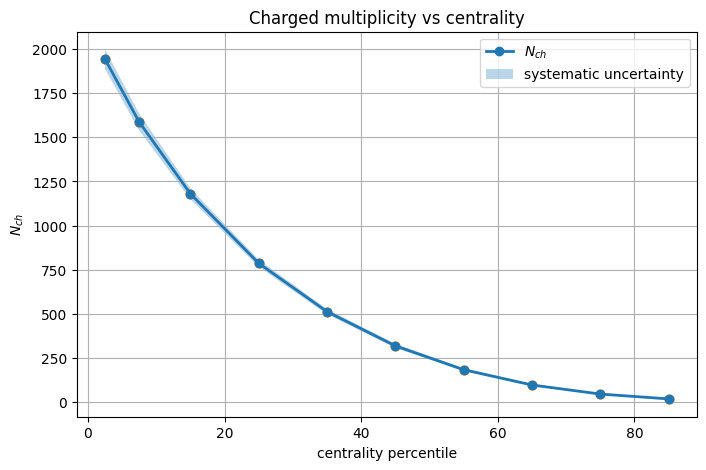

In [10]:
cent_labels = nch_df["Cent [ptc.]"]
cent_mid = np.array([centrality_midpoint(c) for c in cent_labels])

y = nch_df["$N_{Ch}$"].values

# erros
syst = nch_df["syst. +"].values

fig, ax = plt.subplots(figsize=(8,5))

# curva central
ax.plot(
    cent_mid,
    y,
    "o-",
    label=r"$N_{ch}$",
    linewidth=2,
)

# faixa sistemática
ax.fill_between(
    cent_mid,
    y - syst,
    y + syst,
    alpha=0.3,
    label="systematic uncertainty",
)

# pontos
ax.scatter(
    cent_mid,
    y,
    s=40,
)

ax.set_xlabel("centrality percentile")
ax.set_ylabel(r"$N_{ch}$")
ax.set_title("Charged multiplicity vs centrality")

ax.grid(True)
ax.legend()

plt.show()


### Interpretação física

O gráfico mostra uma queda forte de $N_{ch}$ quando vamos de colisões centrais para periféricas.

Isso significa:

- colisões centrais produzem mais partículas;
- há maior densidade de energia;
- há maior probabilidade de comportamento coletivo.



## 4. Gráfico 2 — Razões integradas $K/\pi$ e $p/\pi$ vs centralidade

Agora olhamos para a composição química global da matéria produzida.

As razões integradas são obtidas após integrar em $p_T$. Portanto, elas não mostram a forma do espectro, mas a abundância total relativa de uma espécie em relação aos píons.

$$
\frac{K}{\pi}
=
\frac{\int dp_T\, dN_K/dp_T}{\int dp_T\, dN_\pi/dp_T}
$$

$$
\frac{p}{\pi}
=
\frac{\int dp_T\, dN_p/dp_T}{\int dp_T\, dN_\pi/dp_T}
$$


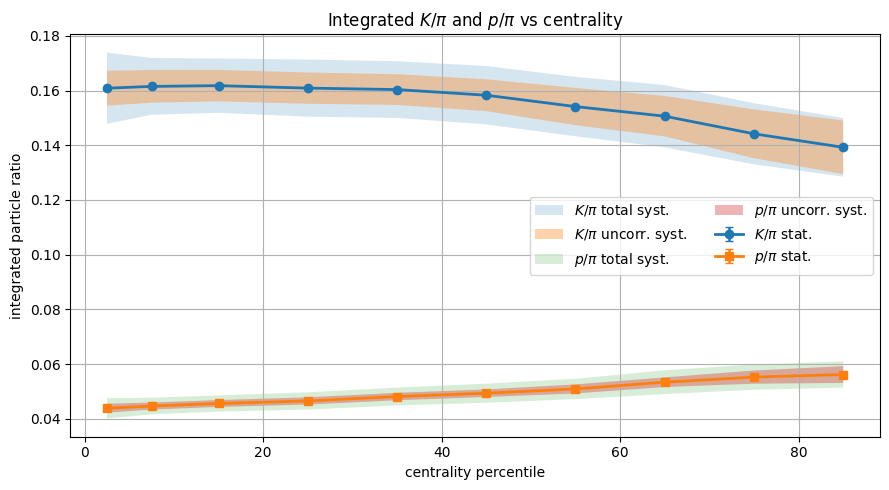

In [15]:
kpi_col = [c for c in kpi_df.columns if "K" in c and "pi" in c][0]
ppi_col = [c for c in ppi_df.columns if "p+pbar" in c and "pi" in c][0]

fig, ax = plt.subplots(figsize=(9,5))

# =========================
# K/pi
# =========================

kpi_y = kpi_df[kpi_col].values

kpi_stat = kpi_df["stat. +"].values
kpi_syst = kpi_df["syst. +"].values
kpi_uncorr = kpi_df["syst. uncorr. +"].values

# faixa sistemática total
ax.fill_between(
    cent_mid,
    kpi_y - kpi_syst,
    kpi_y + kpi_syst,
    alpha=0.18,
    label=r"$K/\pi$ total syst.",
)

# faixa sistemática não correlacionada
ax.fill_between(
    cent_mid,
    kpi_y - kpi_uncorr,
    kpi_y + kpi_uncorr,
    alpha=0.35,
    label=r"$K/\pi$ uncorr. syst.",
)

# barras estatísticas
ax.errorbar(
    cent_mid,
    kpi_y,
    yerr=kpi_stat,
    fmt="o-",
    linewidth=2,
    markersize=6,
    capsize=3,
    elinewidth=1.8,
    label=r"$K/\pi$ stat.",
)

# =========================
# p/pi
# =========================

ppi_y = ppi_df[ppi_col].values

ppi_stat = ppi_df["stat. +"].values
ppi_syst = ppi_df["syst. +"].values
ppi_uncorr = ppi_df["syst. uncorr. +"].values

# faixa sistemática total
ax.fill_between(
    cent_mid,
    ppi_y - ppi_syst,
    ppi_y + ppi_syst,
    alpha=0.18,
    label=r"$p/\pi$ total syst.",
)

# faixa sistemática não correlacionada
ax.fill_between(
    cent_mid,
    ppi_y - ppi_uncorr,
    ppi_y + ppi_uncorr,
    alpha=0.35,
    label=r"$p/\pi$ uncorr. syst.",
)

# barras estatísticas
ax.errorbar(
    cent_mid,
    ppi_y,
    yerr=ppi_stat,
    fmt="s-",
    linewidth=2,
    markersize=6,
    capsize=3,
    elinewidth=1.8,
    label=r"$p/\pi$ stat.",
)

# =========================

ax.set_xlabel("centrality percentile")
ax.set_ylabel("integrated particle ratio")

ax.set_title(
    r"Integrated $K/\pi$ and $p/\pi$ vs centrality"
)

ax.grid(True)
ax.legend(ncol=2)

plt.tight_layout()
plt.show()


### Interpretação física

Este gráfico mostra como a **química global** do sistema muda com a centralidade.

- $K/\pi$ mede a produção relativa de hádrons estranhos em relação aos píons.
- $p/\pi$ mede a produção relativa de bárions em relação aos píons.

É esperado que colisões mais periféricas produzam menor multiplicidade total de partículas, devido ao menor volume e menor energia depositada no sistema, como vimos no grafico anterior. Os resultados indicam que, à medida que o sistema se torna mais periférico, a produção de kaons diminui mais rapidamente do que a de píons, enquanto a produção de prótons diminui mais lentamente que a de píons.

Como o $p_T$ foi integrado, essas razões se aproximam de observáveis termodinâmicos globais, associados a:

- freeze-out químico;
- abundâncias relativas;
- composição hadrônica final.



## 5. Gráfico 3 — Razões integradas como função de $N_{ch}$

A centralidade é uma classificação experimental. Já $N_{ch}$ é uma medida mais direta da multiplicidade final.

Por isso, também é útil plotar as razões integradas contra $N_{ch}$.

Esse gráfico responde:

> como a química final muda conforme a multiplicidade do evento aumenta?


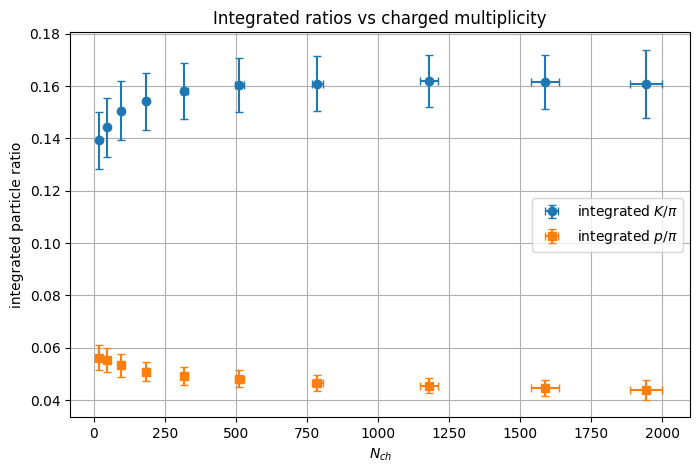

In [16]:

fig, ax = plt.subplots()

ax.errorbar(
    nch_df["$N_{Ch}$"],
    kpi_df[kpi_col],
    xerr=nch_df["syst. +"],
    yerr=np.sqrt(kpi_df["stat. +"]**2 + kpi_df["syst. +"]**2),
    fmt="o",
    capsize=3,
    label=r"integrated $K/\pi$",
)

ax.errorbar(
    nch_df["$N_{Ch}$"],
    ppi_df[ppi_col],
    xerr=nch_df["syst. +"],
    yerr=np.sqrt(ppi_df["stat. +"]**2 + ppi_df["syst. +"]**2),
    fmt="s",
    capsize=3,
    label=r"integrated $p/\pi$",
)

ax.set_xlabel(r"$N_{ch}$")
ax.set_ylabel("integrated particle ratio")
ax.set_title(r"Integrated ratios vs charged multiplicity")
ax.grid(True)
ax.legend()

plt.show()



### Interpretação física

Ao trocar o eixo de centralidade por $N_{ch}$, enfatizamos que a física está sendo organizada pela multiplicidade produzida.

Isso é útil porque:

- $N_{ch}$ é uma grandeza experimental observável;
- a multiplicidade está relacionada à entropia final do sistema.

Esse gráfico prepara a análise posterior dos espectros diferenciais, onde cada classe de centralidade terá seu próprio histograma em $p_T$.



## Conclusão do notebook

Neste primeiro notebook, ficou demonstrado que:

1. A centralidade ordena os eventos de acordo com o tamanho efetivo do overlap nuclear.
2. $N_{ch}$ cresce fortemente em colisões centrais.
3. Razões integradas $K/\pi$ e $p/\pi$ descrevem a química global do sistema.
4. Esses observáveis integrados são a primeira camada de compreensão antes de estudar os espectros diferenciais em $p_T$.

No próximo notebook, a variável principal deixa de ser centralidade e passa a ser:

$$
p_T
$$


ou seja, vamos abrir a estrutura microscópica das partículas produzidas.
